In [ ]:
# mount the data from google drive
from google.colab import drive
from google.colab import files
drive.mount("/content/drive")

# navigate to the project folder
%cd drive/MyDrive/projects/CVPR

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[Errno 2] No such file or directory: 'drive/MyDrive/projects/CVPR'
/content/drive/MyDrive/projects/CVPR/ms-coco


In [ ]:
ls json-files

COCOFreeView_fixations_trainval.json  instances_train2017.json  instances_val2017.json


In [ ]:
!pip install fiftyone

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.7/99.7 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.4/112.4 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 943.0/943.0 kB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.3/139.3 kB 9.5 MB/s eta 0:00:00


In [ ]:
ls ms-coco

annotations/      coco-labels.csv     coco_val2017.zip  json-files/
coco_ann2017.zip  coco_train2017.zip  fixations/        object-arrays/


### download and save fixations

In [ ]:
import json
import pandas as pd

def parse_fixation_data(json_file_path):
    """
    Read fixation data from a JSON file and convert it to a pandas DataFrame.

    Parameters:
    json_file_path (str): Path to the JSON file containing fixation data

    Returns:
    pd.DataFrame: DataFrame containing fixation data with one row per fixation point
    """
    # Read the JSON file
    with open(json_file_path, 'r') as file:
        data = json.load(file)

    # Create a list to store individual fixation data
    fixations = []

    # Process each record in the JSON file
    for record in data:
        # Extract common information for this record
        image_name = record['name']
        subject = record['subject']
        condition = record['condition']
        split = record['split']
        fix_on_target = record['fixOnTarget']
        correct = record['correct']

        # Loop through the fixation points (X, Y, T) for this record
        for i in range(record['length']):
            fixation = {
                'image_name': image_name,
                'subject': subject,
                'condition': condition,
                'split': split,
                'fixOnTarget': fix_on_target,
                'correct': correct,
                'X': record['X'][i],
                'Y': record['Y'][i],
                'T': record['T'][i],
                'fixation_index': i  # Add index to maintain order
            }
            fixations.append(fixation)

    # Create DataFrame from the list of fixations
    df = pd.DataFrame(fixations)

    return df

# Example usage
if __name__ == "__main__":
    # Replace with your actual JSON file path
    file_path = "ms-coco/json-files/COCOFreeView_fixations_trainval.json"

    # Parse the JSON file and create a DataFrame
    fixation_df = parse_fixation_data(file_path)

    # Display the first few rows
    print(fixation_df.head())

    # Optional: save to CSV
    # fixation_df.to_csv("fixations.csv", index=False)

fixation_df.to_csv('coco-freeview-fixation.csv')
my_image_list = fixation_df.image_name.unique()

def get_image_ids_from_filenames(filenames):
    """
    Extracts image IDs from a list of COCO image filenames.

    Args:
        filenames (list of str): List of COCO image filenames (e.g., ["000000123456.jpg", "000000654321.jpg"]).

    Returns:
        list of int: List of extracted image IDs.
    """
    image_ids = [int(filename.split(".")[0]) for filename in filenames if filename.endswith(".jpg")]
    return image_ids

# Example list of COCO image filenames
#file_names = ["000000123456.jpg", "000000654321.jpg", "000000789012.jpg"]

# Extract image IDs
image_ids = get_image_ids_from_filenames(my_image_list)
 # Output: [123456, 654321, 789012]

FileNotFoundError: [Errno 2] No such file or directory: 'ms-coco/json-files/COCOFreeView_fixations_trainval.json'

In [ ]:
df = pd.read_csv('coco-freeview-fixation.csv')
df['image_name'] = df['image_name'].str[:-4]
my_image_list = df.image_name.unique()

,Unnamed: 0,image_name,subject,condition,split,fixOnTarget,correct,X,Y,T,fixation_index
0,0,000000128398,101,freeview,train,False,1,821.5,559.2,316.0,0
1,1,000000128398,101,freeview,train,False,1,957.1,557.7,148.0,1
2,2,000000128398,101,freeview,train,False,1,933.4,531.1,123.0,2
3,3,000000128398,101,freeview,train,False,1,748.6,525.6,224.0,3
4,4,000000128398,101,freeview,train,False,1,530.2,561.4,445.0,4
...,...,...,...,...,...,...,...,...,...,...,...
665000,665000,000000019635,110,freeview,train,False,1,288.1,471.3,262.0,11
665001,665001,000000019635,110,freeview,train,False,1,277.1,468.4,304.0,12
665002,665002,000000019635,110,freeview,train,False,1,257.2,488.9,250.0,13
665003,665003,000000019635,110,freeview,train,False,1,284.4,495.9,219.0,14


In [ ]:
fixation_df.sort_values(by='image_name')

,image_name,subject,condition,split,fixOnTarget,correct,X,Y,T,fixation_index
605663,000000000089.jpg,104,freeview,train,False,1,998.5,813.3,256.0,11
605639,000000000089.jpg,105,freeview,train,False,1,1239.6,360.4,306.0,7
605638,000000000089.jpg,105,freeview,train,False,1,1417.0,344.9,218.0,6
605637,000000000089.jpg,105,freeview,train,False,1,1427.5,292.6,240.0,5
605636,000000000089.jpg,105,freeview,train,False,1,1355.4,301.6,276.0,4
...,...,...,...,...,...,...,...,...,...,...
476223,000000581829.jpg,103,freeview,valid,False,1,553.0,460.2,360.0,7
476222,000000581829.jpg,103,freeview,valid,False,1,786.3,513.4,146.0,6
476221,000000581829.jpg,103,freeview,valid,False,1,799.7,594.7,361.0,5
476237,000000581829.jpg,104,freeview,valid,False,1,776.5,782.4,184.0,6


### download and save annotations

In [ ]:
my_image_list = df.image_name.unique()

In [ ]:
from zipfile import ZipFile, BadZipFile
import os
import shutil

def extract_images_from_zip(zip_path, image_list, output_dir):
    """
    Extracts specific image files from a ZIP archive and saves them to a new folder called 'annotations',
    only if they are in the provided image list.

    Args:
        zip_path: Path to the ZIP file containing images in 'train2017' and 'val2017' folders.
        image_list: List of image filenames to be extracted (without directory paths).
        output_dir: Directory where images should be extracted.
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    try:
        with ZipFile(zip_path, 'r') as zfile:
            # Get all files in the current ZIP
            all_files = zfile.namelist()

            # Filter PNG files in 'train2017' and 'val2017' folders and check if in image_list
            for img_file in all_files:
                print(img_file)
                if img_file.endswith('.png') and ('train2017/' in img_file or 'val2017/' in img_file):
                    img_name = os.path.basename(img_file)  # Get the image filename without path

                    # Check if this image is in the image list
                    if img_name in image_list:
                        # Extract the file to the output directory
                        zfile.extract(img_file, output_dir)

                        # Move file to root of output directory if it was in a subdirectory
                        if os.path.dirname(img_file):
                            src = os.path.join(output_dir, img_file)
                            dst = os.path.join(output_dir, img_name)
                            shutil.move(src, dst)

                        # Clean up empty directories
                        dir_path = os.path.join(output_dir, os.path.dirname(img_file))
                        if os.path.exists(dir_path) and not os.listdir(dir_path):
                            try:
                                os.rmdir(dir_path)
                            except OSError:
                                # Handle nested directories by trying to remove parent dirs
                                parent = dir_path
                                while parent and os.path.exists(parent):
                                    try:
                                        if not os.listdir(parent):
                                            os.rmdir(parent)
                                        parent = os.path.dirname(parent)
                                    except:
                                        break

                        print(f"Extracted: {img_name}")

    except BadZipFile:
        print(f"Error: {zip_path} is not a valid ZIP file")
    except Exception as e:
        print(f"Error processing {zip_path}: {str(e)}")

# Example usage
if __name__ == "__main__":
    # Path to the ZIP file containing 'train2017' and 'val2017' folders
    zip_file = "./stuffthingmaps_trainval2017.zip"

    # Output directory for extracted images
    output_directory = "./annotations"

    # Extract images from the ZIP file if they are in the image list
    extract_images_from_zip(zip_file, my_image_list, output_directory)


Streaming output truncated to the last 5000 lines.
train2017/000000362475.png
train2017/000000165133.png
train2017/000000140197.png
train2017/000000441168.png
train2017/000000129914.png
train2017/000000532734.png
train2017/000000470972.png
train2017/000000344801.png
train2017/000000065655.png
train2017/000000386165.png
train2017/000000271002.png
train2017/000000305705.png
train2017/000000569703.png
train2017/000000567453.png
train2017/000000573395.png
train2017/000000404983.png
train2017/000000431686.png
train2017/000000387645.png
train2017/000000534112.png
train2017/000000038152.png
train2017/000000129100.png
train2017/000000313057.png
train2017/000000371244.png
train2017/000000158786.png
train2017/000000278435.png
train2017/000000103341.png
train2017/000000216685.png
train2017/000000220917.png
train2017/000000126296.png
train2017/000000443635.png
train2017/000000562075.png
train2017/000000091009.png
train2017/000000352565.png
train2017/000000323132.png
train2017/000000540922.png
trai

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



train2017/000000436407.png
train2017/000000194532.png
train2017/000000314778.png
train2017/000000422517.png
train2017/000000151074.png
train2017/000000395714.png
train2017/000000407080.png
train2017/000000364123.png
train2017/000000474732.png
train2017/000000401652.png
train2017/000000260970.png
train2017/000000394682.png
train2017/000000186472.png
train2017/000000343185.png
train2017/000000502620.png
train2017/000000335585.png
train2017/000000087936.png
train2017/000000013868.png
train2017/000000297895.png
train2017/000000339965.png
train2017/000000407039.png
train2017/000000394180.png
train2017/000000447552.png
train2017/000000220347.png
train2017/000000207943.png
train2017/000000340995.png
train2017/000000290398.png
train2017/000000410252.png
train2017/000000269088.png
train2017/000000048256.png
train2017/000000555583.png
train2017/000000130786.png
train2017/000000214699.png
train2017/000000308605.png
train2017/000000365094.png
train2017/000000370266.png
train2017/000000581886.png
t

In [ ]:
img_name

NameError: name 'img_name' is not defined

### download and save images

In [ ]:
from zipfile import ZipFile, BadZipFile
import os
import shutil

def extract_images_from_multiple_zips(zip_paths, image_list, output_dir):
    """
    Extract specific image files from multiple ZIP archives based on a list of filenames.
    All images are saved to a single output folder.

    Args:
        zip_paths: List of paths to ZIP files
        image_list: List of image filenames or path to a text file with filenames (one per line)
        output_dir: Directory to extract all files to
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    # Handle file input for image list
    if isinstance(image_list, str) and os.path.isfile(image_list):
        with open(image_list, 'r') as f:
            images_to_extract = [line.strip() for line in f if line.strip()]
    else:
        images_to_extract = image_list

    # Track overall statistics
    total_found = 0
    remaining_images = set(images_to_extract)  # Track which images we still need to find
    found_in_zips = {zip_path: 0 for zip_path in zip_paths}  # Count per ZIP

    print(f"Looking for {len(images_to_extract)} images across {len(zip_paths)} ZIP files...")

    # Process each ZIP file
    for zip_path in zip_paths:
        if not os.path.exists(zip_path):
            print(f"Warning: ZIP file not found - {zip_path}")
            continue

        try:
            with ZipFile(zip_path, 'r') as zfile:
                # Get all files in the current ZIP
                all_files = zfile.namelist()

                # Check each remaining image
                images_to_remove = set()  # Images to remove from remaining set after this ZIP

                for img_file in remaining_images:
                    # Check various possible paths
                    possible_paths = [
                        img_file,
                        os.path.basename(img_file),
                        f"train2017/{img_file}",  # For COCO common directory structure
                        f"val2017/{img_file}",
                        f"test2017/{img_file}"
                    ]

                    for path in possible_paths:
                        if path in all_files:
                            # Extract the file
                            zfile.extract(path, output_dir)

                            # Move file to root of output directory if it was in a subdirectory
                            if os.path.dirname(path):
                                src = os.path.join(output_dir, path)
                                dst = os.path.join(output_dir, os.path.basename(path))
                                shutil.move(src, dst)

                                # Clean up empty directories
                                dir_path = os.path.join(output_dir, os.path.dirname(path))
                                if os.path.exists(dir_path) and not os.listdir(dir_path):
                                    try:
                                        os.rmdir(dir_path)
                                    except OSError:
                                        # Handle nested directories by trying to remove parent dirs
                                        parent = dir_path
                                        while parent and os.path.exists(parent):
                                            try:
                                                if not os.listdir(parent):
                                                    os.rmdir(parent)
                                                parent = os.path.dirname(parent)
                                            except:
                                                break

                            # Update statistics
                            found_in_zips[zip_path] += 1
                            total_found += 1
                            images_to_remove.add(img_file)

                            print(f"Extracted: {os.path.basename(path)} (from {os.path.basename(zip_path)})")
                            break  # Found this image, move to next

                # Remove found images from the remaining set
                remaining_images -= images_to_remove

                print(f"Processed {os.path.basename(zip_path)}: found {found_in_zips[zip_path]} images")

                # If we've found all images, no need to check more ZIPs
                if not remaining_images:
                    print("All requested images have been found!")
                    break

        except BadZipFile:
            print(f"Error: {zip_path} is not a valid ZIP file")
        except Exception as e:
            print(f"Error processing {zip_path}: {str(e)}")

    # Final report
    print("\nExtraction complete:")
    print(f"- Total images requested: {len(images_to_extract)}")
    print(f"- Total images found and extracted: {total_found}")

    # Report per ZIP file
    for zip_path, count in found_in_zips.items():
        if count > 0:
            print(f"  - Found in {os.path.basename(zip_path)}: {count} images")

    # Report missing images
    if remaining_images:
        print(f"- Images not found in any ZIP: {len(remaining_images)}")
        if len(remaining_images) <= 10:
            print(f"  - Missing files: {', '.join(remaining_images)}")
        else:
            print(f"  - First 10 missing files: {', '.join(list(remaining_images)[:10])}...")

# Example usage
if __name__ == "__main__":
    # COCO dataset ZIP files
    zip_files = [
        "./coco_train2017.zip",
        "./coco_val2017.zip"
    ]

    output_directory = "./ms-coco/images"


    # Example: From a text file containing image filenames
    # image_list_file = "images_to_extract.txt"

    # Extract the specified images from both ZIP files
    extract_images_from_multiple_zips(zip_files, my_image_list, output_directory)

    # Alternative: Using a file list
    # extract_images_from_multiple_zips(zip_files, image_list_file, output_directory)

Looking for 4317 images across 2 ZIP files...
Extracted: 000000034854.jpg (from coco_train2017.zip)
Extracted: 000000358667.jpg (from coco_train2017.zip)
Extracted: 000000186784.jpg (from coco_train2017.zip)
Extracted: 000000392839.jpg (from coco_train2017.zip)
Extracted: 000000016741.jpg (from coco_train2017.zip)
Extracted: 000000010856.jpg (from coco_train2017.zip)
Extracted: 000000198473.jpg (from coco_train2017.zip)
Extracted: 000000407808.jpg (from coco_train2017.zip)
Extracted: 000000266001.jpg (from coco_train2017.zip)
Extracted: 000000103676.jpg (from coco_train2017.zip)
Extracted: 000000349263.jpg (from coco_train2017.zip)
Extracted: 000000164725.jpg (from coco_train2017.zip)
Extracted: 000000548608.jpg (from coco_train2017.zip)
Extracted: 000000288723.jpg (from coco_train2017.zip)
Extracted: 000000572180.jpg (from coco_train2017.zip)
Extracted: 000000262442.jpg (from coco_train2017.zip)
Extracted: 000000111348.jpg (from coco_train2017.zip)
Extracted: 000000172319.jpg (from co

### coco-stuff segmentations

### download and save segmentations into arrays

In [ ]:
import fiftyone as fo
import fiftyone.zoo as foz
import numpy as np
import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# Load COCO-2017 dataset with segmentation masks
dataset = foz.load_zoo_dataset(
    "coco-2017",
    label_types=["segmentations"],
)


INFO:fiftyone.zoo.datasets:Downloading split 'train' to '/root/fiftyone/coco-2017/train' if necessary


INFO:fiftyone.utils.coco:Downloading annotations to '/root/fiftyone/coco-2017/tmp-download/annotations_trainval2017.zip'


 100% |██████|    1.9Gb/1.9Gb [2.5s elapsed, 0s remaining, 796.3Mb/s]       


INFO:eta.core.utils: 100% |██████|    1.9Gb/1.9Gb [2.5s elapsed, 0s remaining, 796.3Mb/s]       


Extracting annotations to '/root/fiftyone/coco-2017/raw/instances_train2017.json'


...

 100% |█████████████| 40670/40670 [12.8s elapsed, 0s remaining, 3.5K samples/s]      


INFO:eta.core.utils: 100% |█████████████| 40670/40670 [12.8s elapsed, 0s remaining, 3.5K samples/s]      


Dataset 'coco-2017' created


INFO:fiftyone.zoo.datasets:Dataset 'coco-2017' created


ValueError: Either `dataset_type` or `dataset_exporter` must be provided

In [ ]:

# Define directory to save segmentations
output_dir = "segmentations_np"
os.makedirs(output_dir, exist_ok=True)

# Define valid image IDs (replace with actual list of image IDs)
valid_image_ids = set(image_ids)  # You should define image_ids before this

# List to store metadata for the DataFrame
data = []

instance_id = 0
# Iterate over dataset samples
for sample in dataset:
    image_id = int(sample.filepath.split("/")[-1].split(".")[0])  # Extract numeric ID

    # Skip if image_id is not in the valid set
    if image_id not in valid_image_ids:
        continue

    # Get segmentation masks
    detections = sample.ground_truth
    image_path = sample.filepath
    if detections is not None and hasattr(detections, "detections"):
        metadata = sample.metadata
        height, width = metadata.height, metadata.width

        # Create an empty mask array (same size as image)
        image_mask = np.zeros((height, width), dtype=np.uint16)  # Use uint16 for multiple instances

        # Iterate over detections and properly place masks
        for detection in detections.detections:
            if detection.mask is not None:
                instance_id = instance_id + 1
                # Convert the instance segmentation to a full-size mask
                frame_size = (sample.metadata["width"], sample.metadata["height"])
                segmentation = detection.to_segmentation(frame_size = frame_size)
                full_img_mask = segmentation.mask  # Convert to binary mask

                # Apply the mask to the full image mask
                image_mask[full_img_mask > 0] = instance_id  # Apply mask to image

                # Store metadata
                label = detection.label if hasattr(detection, "label") else "Unknown"
                data.append({"image_id": image_id, "instance_id": instance_id, "label": label, "image_path": image_path})

        # Save the full segmentation mask (image + mask)
        np.save(os.path.join(output_dir, f"{image_id}.npy"), image_mask)

        print(f"Image {image_id}: {len(detections.detections)} segmentations saved")

# Convert collected data to a Pandas DataFrame
df = pd.DataFrame(data)

# Return the DataFrame
df.to_csv('coco-labels.csv')


Image 89: 10 segmentations saved
Image 194: 2 segmentations saved
Image 196: 42 segmentations saved
Image 387: 3 segmentations saved
Image 560: 5 segmentations saved
Image 584: 14 segmentations saved
Image 605: 4 segmentations saved
Image 643: 21 segmentations saved
Image 1306: 13 segmentations saved
Image 1347: 9 segmentations saved
Image 1355: 9 segmentations saved
Image 1455: 2 segmentations saved
Image 1771: 2 segmentations saved
Image 1906: 26 segmentations saved
Image 2024: 1 segmentations saved
Image 2270: 13 segmentations saved
Image 2284: 8 segmentations saved
Image 2347: 9 segmentations saved
Image 2429: 19 segmentations saved
Image 2434: 4 segmentations saved
Image 2448: 9 segmentations saved
Image 2608: 21 segmentations saved
Image 2697: 29 segmentations saved
Image 2759: 16 segmentations saved
Image 3219: 7 segmentations saved
Image 3671: 6 segmentations saved
Image 3703: 12 segmentations saved
Image 3877: 19 segmentations saved
Image 3899: 10 segmentations saved
Image 399

In [ ]:

# Export dataset to a COCO format
dataset.export(
    export_dir="coco_train2017/",
    dataset_type=fo.types.COCODetectionDataset
)

NameError: name 'dataset' is not defined

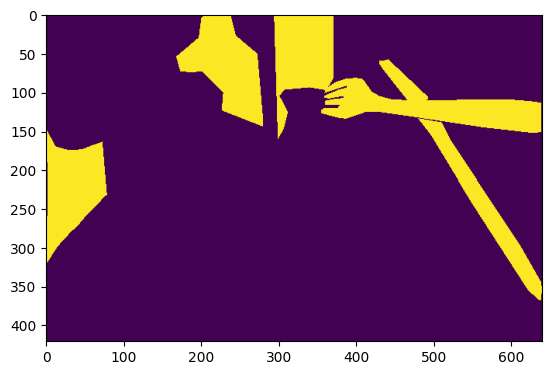

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
test_arr = np.load('segmentations_np/559513.npy')
plt.imshow(test_arr)

In [ ]:
np.unique(test_arr)

array([    0, 35224, 35225, 35226, 35227, 35228], dtype=uint16)

In [ ]:
image_path = '/root/fiftyone/coco-2017/train/data/000000000387.jpg'

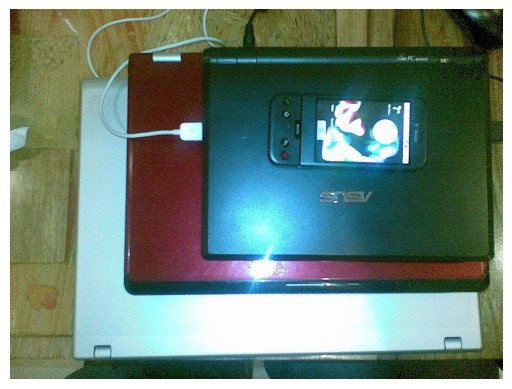

In [ ]:
# Get the image file path
#image_path = sample.filepath
# Load the image using PIL (you can also use OpenCV if preferred)
image = Image.open(image_path)

# Display the image using matplotlib
plt.imshow(image)
plt.axis('off')  # Turn off axis
plt.show()